In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# Set the root path as if it's being ran from the project root
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

In [107]:
import pygad
import numpy as np
import torch
import os
from ga.components.ga import on_crossover_func, on_generation_func, calculate_dynamic_probs
from ga.components.fitness import constrained_fitness_func
from ga.components.mutation import paper_style_mutation, random_float_mutation, custom_mutation
from ga.components.crossover import apply_pixel_cleaning
from ga.components.model import load_model, evaluate_without_perturbation, evaluate_with_perturbation
from ga.utils import get_dataloader, visualize_images_batch,visualize_image, visualize_perturbation, compute_pixel_statistics, load_config
from ga.plot import plot_time_to_convergence, plot_psnr, plot_snr, plot_confidence_score, plot_misclassification, plot_avg_mse, plot_norm

In [32]:
# Use GPU instead of CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Parameters

In [33]:
config = load_config()

In [34]:
# num_generations =num_generations=config["ga"]["num_generations"]
# num_parents_mating=config["ga"]["num_parents_mating"]
# sol_per_pop=config["ga"]["sol_per_pop"]
# init_range_low=config["ga"]["init_range_low"]
# init_range_high=config["ga"]["init_range_high"]
# mutation_percent_genes=config["ga"]["mutation_percent_genes"]

# model_type = config["model"]["model_type"]
# batch_size = config["model"]["batch_size"]

# visualize = config["visualization"]["visualize"]
# visualize_every = config["visualization"]["visualize_every"]


# Model

In [35]:
model = load_model(config["model"]["model_type"], device=device)

Loading model: googlenet
Using device: mps


# Loading

In [36]:
# Load
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
image_dir = os.path.join(project_root, "nn/data/imagenet/val")
dataloader = get_dataloader(config["model"]["batch_size"], image_dir)


## Compute statistics - no need to run now

In [37]:
# Compute the pixel mean and standard deviation for each pixel across the entire dataset - for constrained fitness func

# pixel_mean, pixel_std = compute_pixel_statistics(dataloader)

# Roughly 0.04, 1.18, since we already normalize the dataset

In [38]:
# First batch
input_batch, labels = next(iter(dataloader))
input_batch, labels = input_batch.to(device), labels.to(device)

# Collect top perturbations from each generation
top_perturbations = []

# GA Config


--- Generation 1 Completed ---
Best Fitness = -3.7430235807675194
Best perturbation norm: 105.9822998046875
Best perturbation MSE: 0.8986228704452515
Misclassification score: 0.6875
Confidence score: 0.6664254222068848
New crossover & mutation probabilities: 0.8921875, 0.59375

--- Generation 2 Completed ---
Best Fitness = -2.9161374569852314
Best perturbation norm: 100.61553955078125
Best perturbation MSE: 0.8968809843063354
Misclassification score: 0.671875
Confidence score: 0.6664254222068848
New crossover & mutation probabilities: 0.884375, 0.5875

--- Generation 3 Completed ---
Best Fitness = -2.1028317398786243
Best perturbation norm: 95.33257293701172
Best perturbation MSE: 0.8952879309654236
Misclassification score: 0.65625
Confidence score: 0.6664254222068848
New crossover & mutation probabilities: 0.8765625, 0.5812499999999999

--- Generation 4 Completed ---
Best Fitness = -1.3399253975202043
Best perturbation norm: 90.39540100097656
Best perturbation MSE: 0.893875002861023


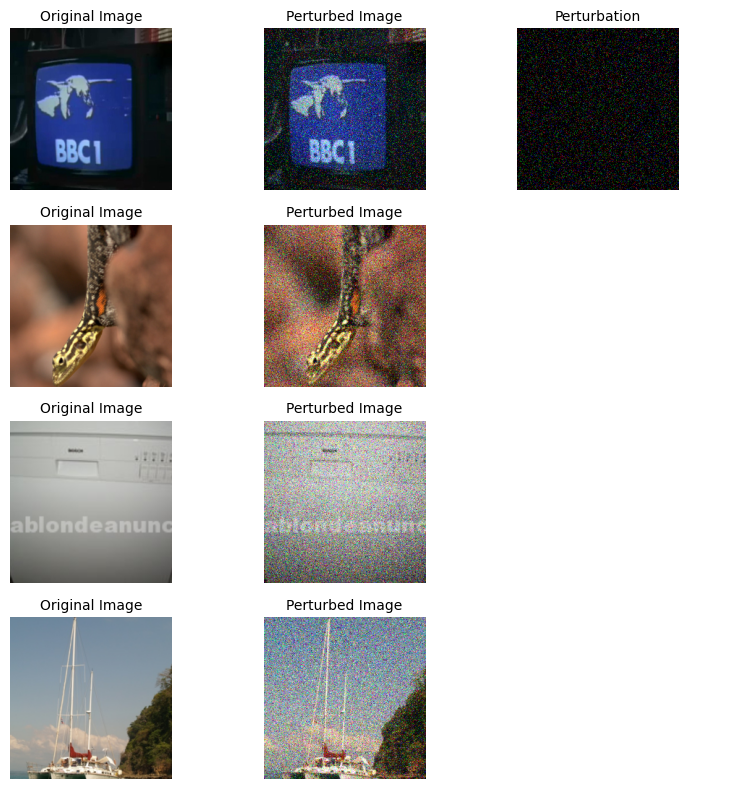

New crossover & mutation probabilities: 0.775, 0.5

--- Generation 17 Completed ---
Best Fitness = 0.640625
Best perturbation norm: 67.152099609375
Best perturbation MSE: 0.8827540278434753
Misclassification score: 0.640625
Confidence score: 0.5486931090711096
New crossover & mutation probabilities: 0.7671875, 0.49374999999999997

--- Generation 18 Completed ---
Best Fitness = 0.640625
Best perturbation norm: 64.31478881835938
Best perturbation MSE: 0.8821524977684021
Misclassification score: 0.640625
Confidence score: 0.5486931090711096
New crossover & mutation probabilities: 0.759375, 0.4875

--- Generation 19 Completed ---
Best Fitness = 0.65625
Best perturbation norm: 64.2903823852539
Best perturbation MSE: 0.8821419477462769
Misclassification score: 0.65625
Confidence score: 0.5486931090711096
New crossover & mutation probabilities: 0.7515625, 0.48124999999999996

--- Generation 20 Completed ---
Best Fitness = 0.640625
Best perturbation norm: 64.41614532470703
Best perturbation MS

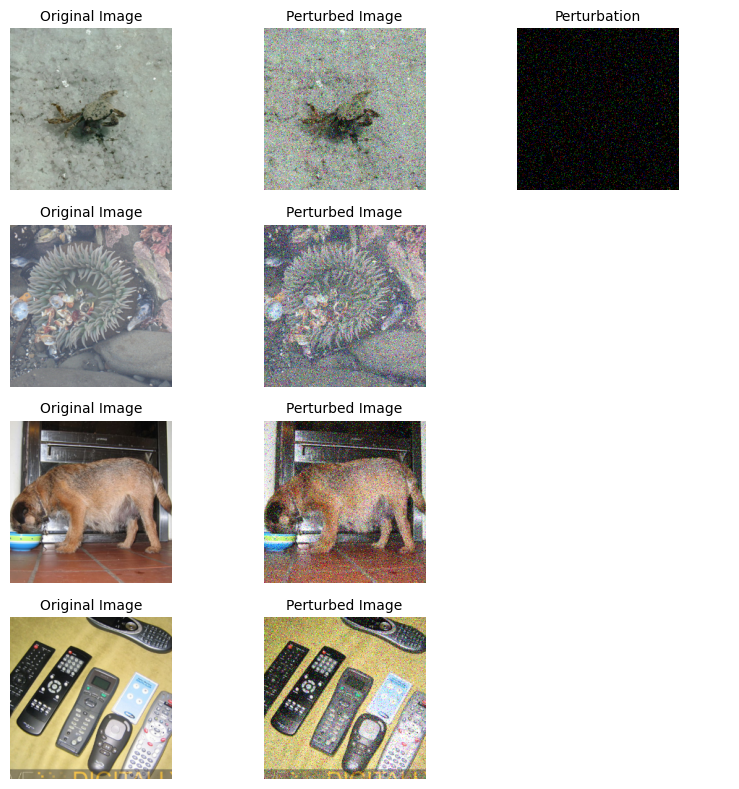

New crossover & mutation probabilities: 0.65, 0.4

--- Generation 33 Completed ---
Best Fitness = 0.5625
Best perturbation norm: 52.631446838378906
Best perturbation MSE: 0.6657651662826538
Misclassification score: 0.5625
Confidence score: 0.5547392022617714
New crossover & mutation probabilities: 0.6421875, 0.39375

--- Generation 34 Completed ---
Best Fitness = 0.5625
Best perturbation norm: 52.12200164794922
Best perturbation MSE: 0.6656634211540222
Misclassification score: 0.5625
Confidence score: 0.5547392022617714
New crossover & mutation probabilities: 0.634375, 0.38749999999999996

--- Generation 35 Completed ---
Best Fitness = 0.5625
Best perturbation norm: 52.08247375488281
Best perturbation MSE: 0.6656498908996582
Misclassification score: 0.5625
Confidence score: 0.5547392022617714
New crossover & mutation probabilities: 0.6265625, 0.38125

--- Generation 36 Completed ---
Best Fitness = 0.5625
Best perturbation norm: 50.139381408691406
Best perturbation MSE: 0.66527640819549

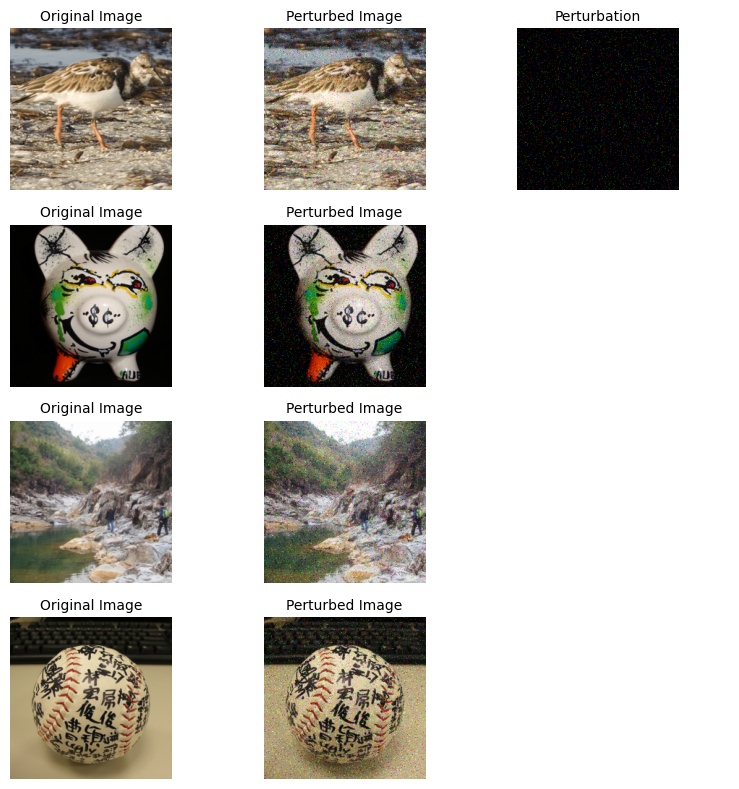

New crossover & mutation probabilities: 0.525, 0.3

--- Generation 49 Completed ---
Best Fitness = 0.578125
Best perturbation norm: 42.196720123291016
Best perturbation MSE: 0.8385970592498779
Misclassification score: 0.578125
Confidence score: 0.5393935450501885
New crossover & mutation probabilities: 0.5171875, 0.29375

--- Generation 50 Completed ---
Best Fitness = 0.59375
Best perturbation norm: 42.492576599121094
Best perturbation MSE: 0.8386461138725281
Misclassification score: 0.59375
Confidence score: 0.5393935450501885
New crossover & mutation probabilities: 0.509375, 0.2875

--- Generation 51 Completed ---
Best Fitness = 0.578125
Best perturbation norm: 41.66020584106445
Best perturbation MSE: 0.8385211229324341
Misclassification score: 0.578125
Confidence score: 0.5393935450501885
New crossover & mutation probabilities: 0.5015625, 0.28125

--- Generation 52 Completed ---
Best Fitness = 0.578125
Best perturbation norm: 40.96855545043945
Best perturbation MSE: 0.83841824531555

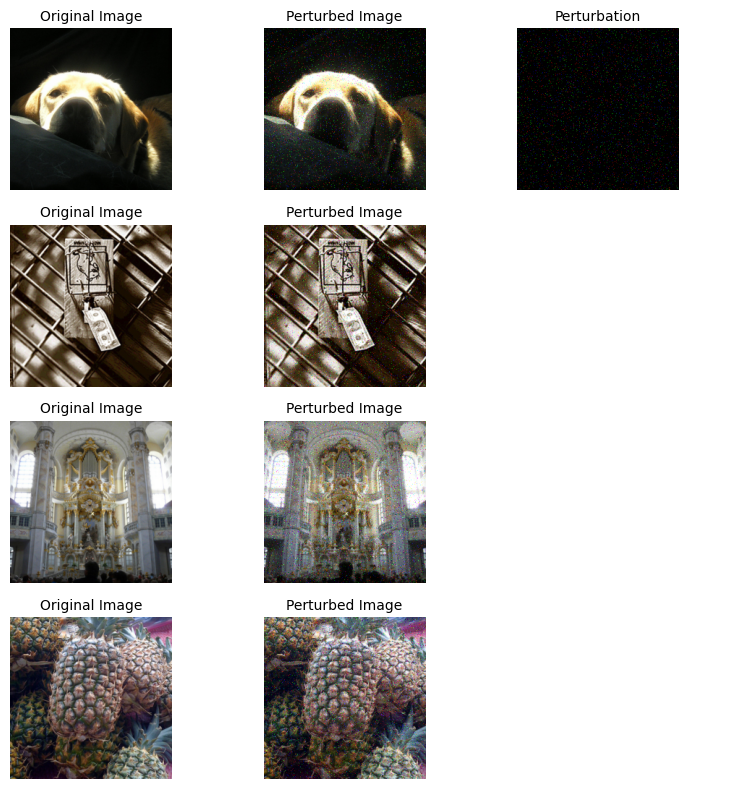

New crossover & mutation probabilities: 0.4, 0.2


In [100]:
config = load_config()
top_perturbations = []
metrics_log = {
    "gen": [],
    "norm": [],
    "avg_mse": [],
    "misclassification": [],
    "confidence": [],
    # "psnr_list": [],
    # "snr_list": [],
}

ga_instance = pygad.GA(
    num_generations=config["ga"]["num_generations"],
    num_parents_mating=config["ga"]["num_parents_mating"],
    sol_per_pop=config["ga"]["sol_per_pop"],
    num_genes=3*224*224,
    gene_type=float,
    init_range_low=config["ga"]["init_range_low"],
    init_range_high=config["ga"]["init_range_high"],
    parent_selection_type=config["ga"]["parent_selection_type"],
    keep_elitism=config["ga"]["keep_elitism"],
    keep_parents=config["ga"]["keep_parents"],
    crossover_type=config["crossover"]["crossover_type"],
    crossover_probability=config["crossover"]["p_crossover_init"],
    mutation_type=lambda ga_inst, offspring: paper_style_mutation(ga_inst, offspring, config["mutation"]["p_mutation_init"], config["mutation"]["p_flip"]),
    fitness_func=lambda ga_inst, solution, solution_idx: constrained_fitness_func(
        ga_inst, solution, solution_idx, model, config["fitness"]["epsilon_init"], config["fitness"]["epsilon_end"], config["fitness"]["penalty_factor"]
    ),
    on_generation=lambda ga_inst: on_generation_func(ga_inst, dataloader, model,device, config, metrics_log),
    on_crossover=lambda ga_inst, offspring: on_crossover_func(ga_inst, offspring, config),
)

ga_instance.user_data={
    "input_batch": input_batch,
    "labels": labels,
    "top_perturbations": top_perturbations,
    "epsilon": config["fitness"]["epsilon_init"]
}



ga_instance.run()

In [52]:
# After the run
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Best solution fitness: {solution_fitness}") # Might be the penultimate best fitness??

Best solution fitness: 0.5625


# Calculating Universal Perturbation

In [102]:
top_perturbations = ga_instance.user_data["top_perturbations"]
len(top_perturbations)

0

torch.Size([3, 224, 224])
Universal perturbation created.


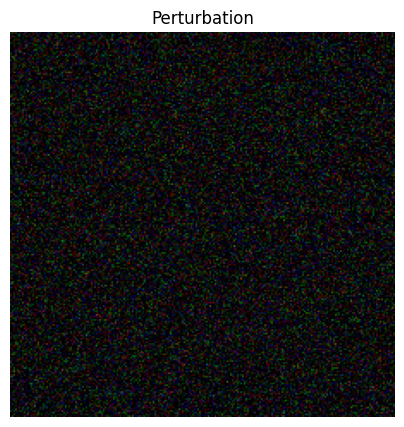

In [140]:
# Stacking the top perturbations together

# if len(top_perturbations) > 0:
#     universal_perturbation = torch.mean(torch.stack(top_perturbations), dim=0)
#     print(universal_perturbation.shape)
#     print(f"Universal perturbation created.")
#     visualize_perturbation(universal_perturbation)

In [101]:
# Take the last one only (much smaller norm)
universal_perturbation = top_perturbations[62]
visualize_perturbation(universal_perturbation)

IndexError: list index out of range

# Plotting

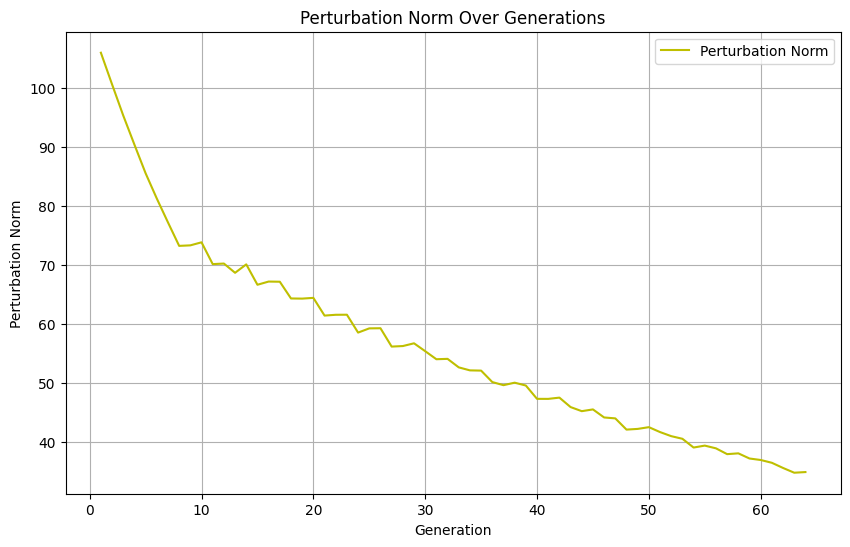

In [108]:
plot_norm(metrics_log)

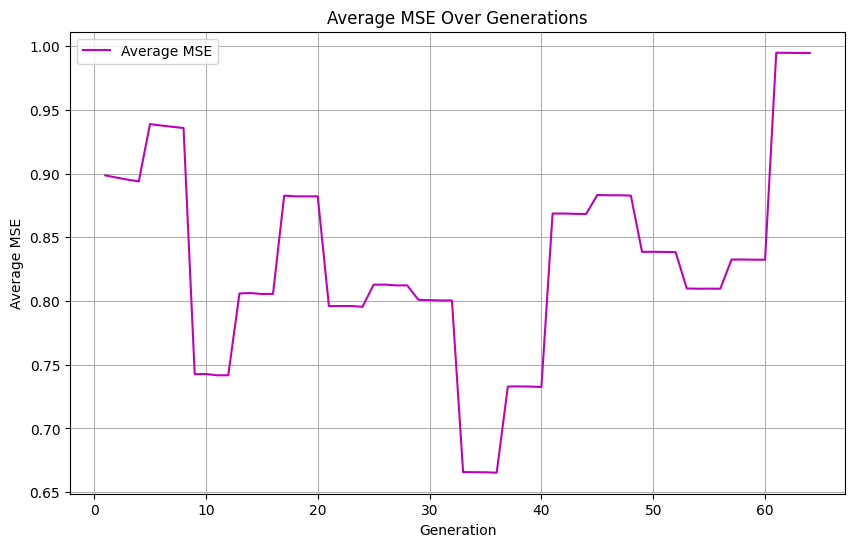

In [105]:
plot_avg_mse(metrics_log)

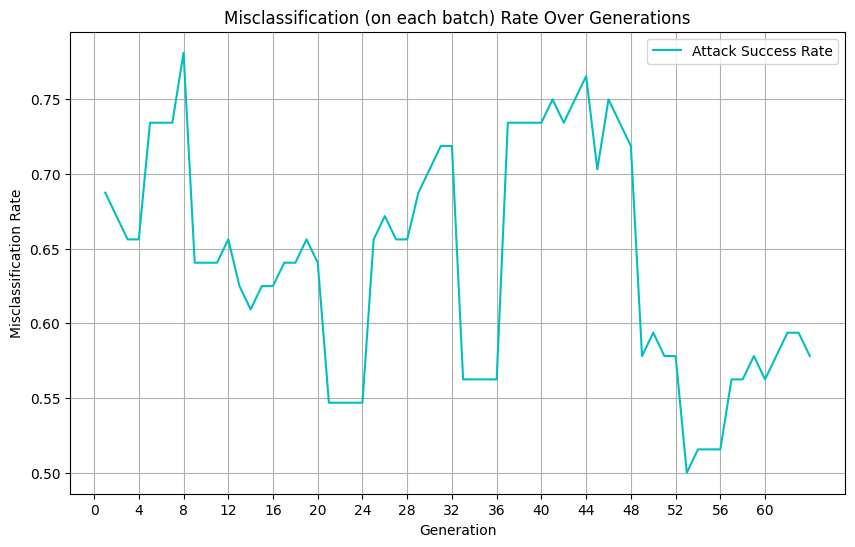

In [112]:
plot_misclassification(metrics_log)

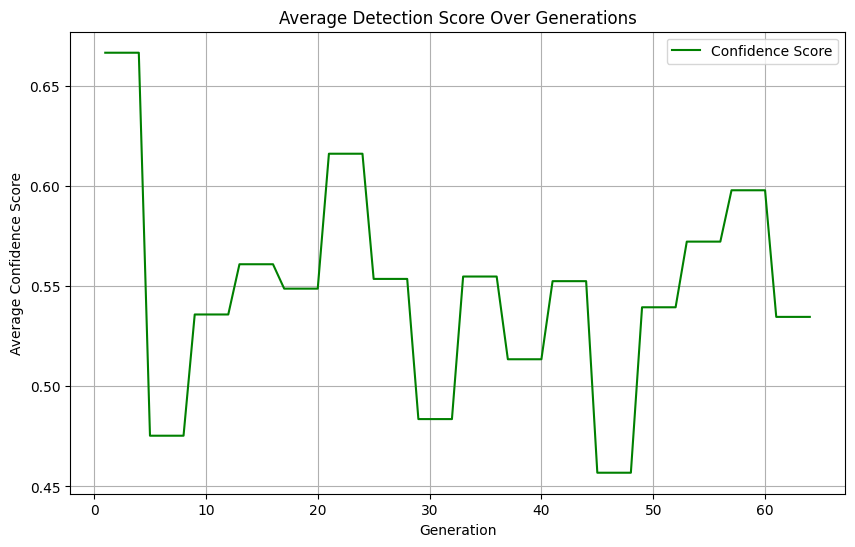

In [110]:
plot_confidence_score(metrics_log)

# Metrics

### GoogLeNet
(4 min)

In [155]:
evaluate_without_perturbation(model, dataloader, device)
# 0.6977

Using device: mps
Accuracy without perturbation: 0.69772


0.69772

In [95]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)
# 9/24: 0.37964

# 12/24: 0.39556 (mean (higher norm)), 0.4017 (last one only)

Using device: mps
Accuracy with perturbation: 0.40932


0.40932

### ViT b 16

In [ ]:
evaluate_without_perturbation(model, dataloader, device)
# 0.811
# 13 mins

Using device: cpu


RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [ ]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)